In [58]:
import numpy as np
import matplotlib.pyplot as plt
from velocity_model import depression_model,sinusoidal_interface_model
from source import ricker
from guassian_smoothing import smoothing_velocity_model
from boundary import damping_boundary
from forward_acoustic_solver import forward_acoustic_solver
from fd_coefficients import fd_coefficients
from imageing import RTM_imaging
from scipy.ndimage import laplace

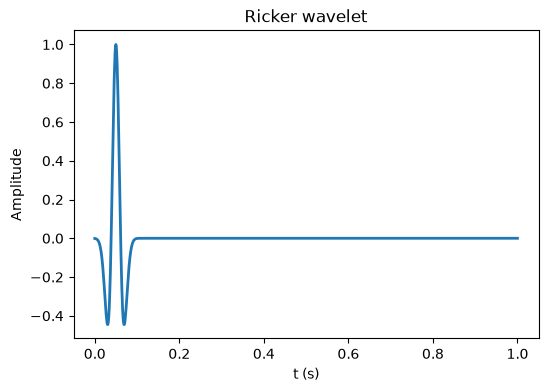

[  0  20  40  60  80 100 120 140 160 180 200 220 240 260 280 300]


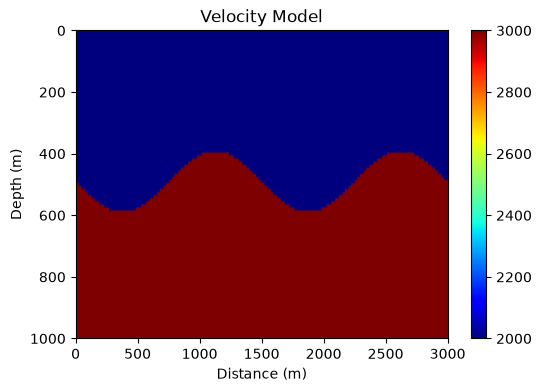

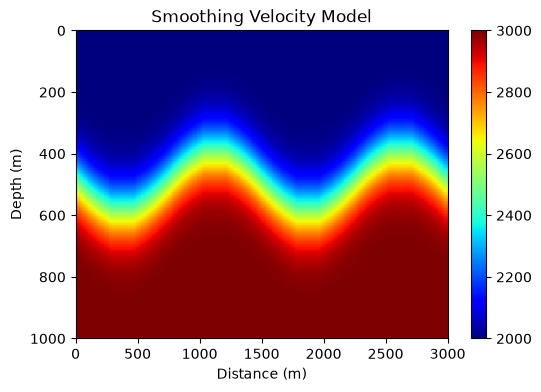

In [69]:
#===========================================
#  Parameters
#===========================================
nx = 301
nz = 101
dx = 10.0
dz = 10.0
x_max = (nx - 1) * dx
z_max = (nz - 1) * dz
dt = 0.001
tmax = 1.0
nt = int(tmax / dt) + 1
t = np.arange(0, tmax + dt, dt)
#===========================================
# Source
#===========================================
f0 = 20.0
t0 = 1/f0
wavelet = ricker(t,f0,t0)
wavelet = np.asarray(wavelet, dtype=np.float64)
# Plot wavelet
plt.figure(figsize=(6, 4))
plt.plot(t,wavelet,linewidth=2)
plt.xlabel("t (s)")
plt.ylabel("Amplitude")
plt.title("Ricker wavelet")
plt.show()
#===========================================
# Source position
#===========================================
# ix_src = [25,50,75,100,125,150,175,200,225,250,275]
# ix_src = [140,150,160]
ix_src = np.arange(0,320,20)
iz_src = 1
print(ix_src)
#===========================================
# Velocity model
#===========================================
'''
velocity_model = depression_model(
        nx=nx,
        nz=nz,
        dx=dx,
        dz=dz,
        velocity_top=2000.0,
        velocity_bottom=3000.0,
        depth0=500.0,
        center_x=1500.0,
        depth_amplitude=200.0,
        width=200.0
    )
'''
velocity_model = sinusoidal_interface_model(
        nx=nx,
        nz=nz,
        dx=dx,
        dz=dz,
        velocity_top=2000.0,
        velocity_bottom=3000.0,
        depth0=500.0,
        amplitude=100.0,
        wavelength=1500.0
)
velocity = np.asarray(velocity_model,dtype=np.float64)
# Plot velocity model
plt.figure(figsize=(6, 4))
plt.imshow(
        velocity,
        extent=[0,x_max,z_max,0],
        aspect='auto',
        cmap="jet",
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title("Velocity Model")
plt.colorbar()
plt.show()
#===========================================
# Smoothing velocity model
#===========================================
velocity_smooth = smoothing_velocity_model(velocity, sigma_x=1.0, sigma_z=10.0)
# Plot velocity model
plt.figure(figsize=(6, 4))
plt.imshow(
        velocity_smooth,
        extent=[0,x_max,z_max,0],
        aspect='auto',
        cmap="jet",
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title("Smoothing Velocity Model")
plt.colorbar()
plt.show()


In [70]:
# Damping boundary
n_abs = 40
velocity_ext, sigma = damping_boundary(
    velocity,
    dx,
    dz,
    n_abs,
    reflection=1e-6,
    power=2
)
# Finite-difference order
order = 8
coeff = fd_coefficients(order)
coeff = np.asarray(coeff,dtype=np.float64)

snapshot_steps = np.array([100])

#===========================================
# Generate shotgather via forward modeling
#===========================================
shotgather = np.zeros((len(ix_src),len(wavelet),velocity.shape[1]),dtype=np.float64)
for i in range(len(ix_src)):
    shotgather[i] = forward_acoustic_solver(
        velocity_ext,
        wavelet,
        coeff,
        ix_src[i],
        iz_src,
        dx,
        dz,
        dt,
        snapshot_steps,
        sigma,
        n_abs,
        )[1]

Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s


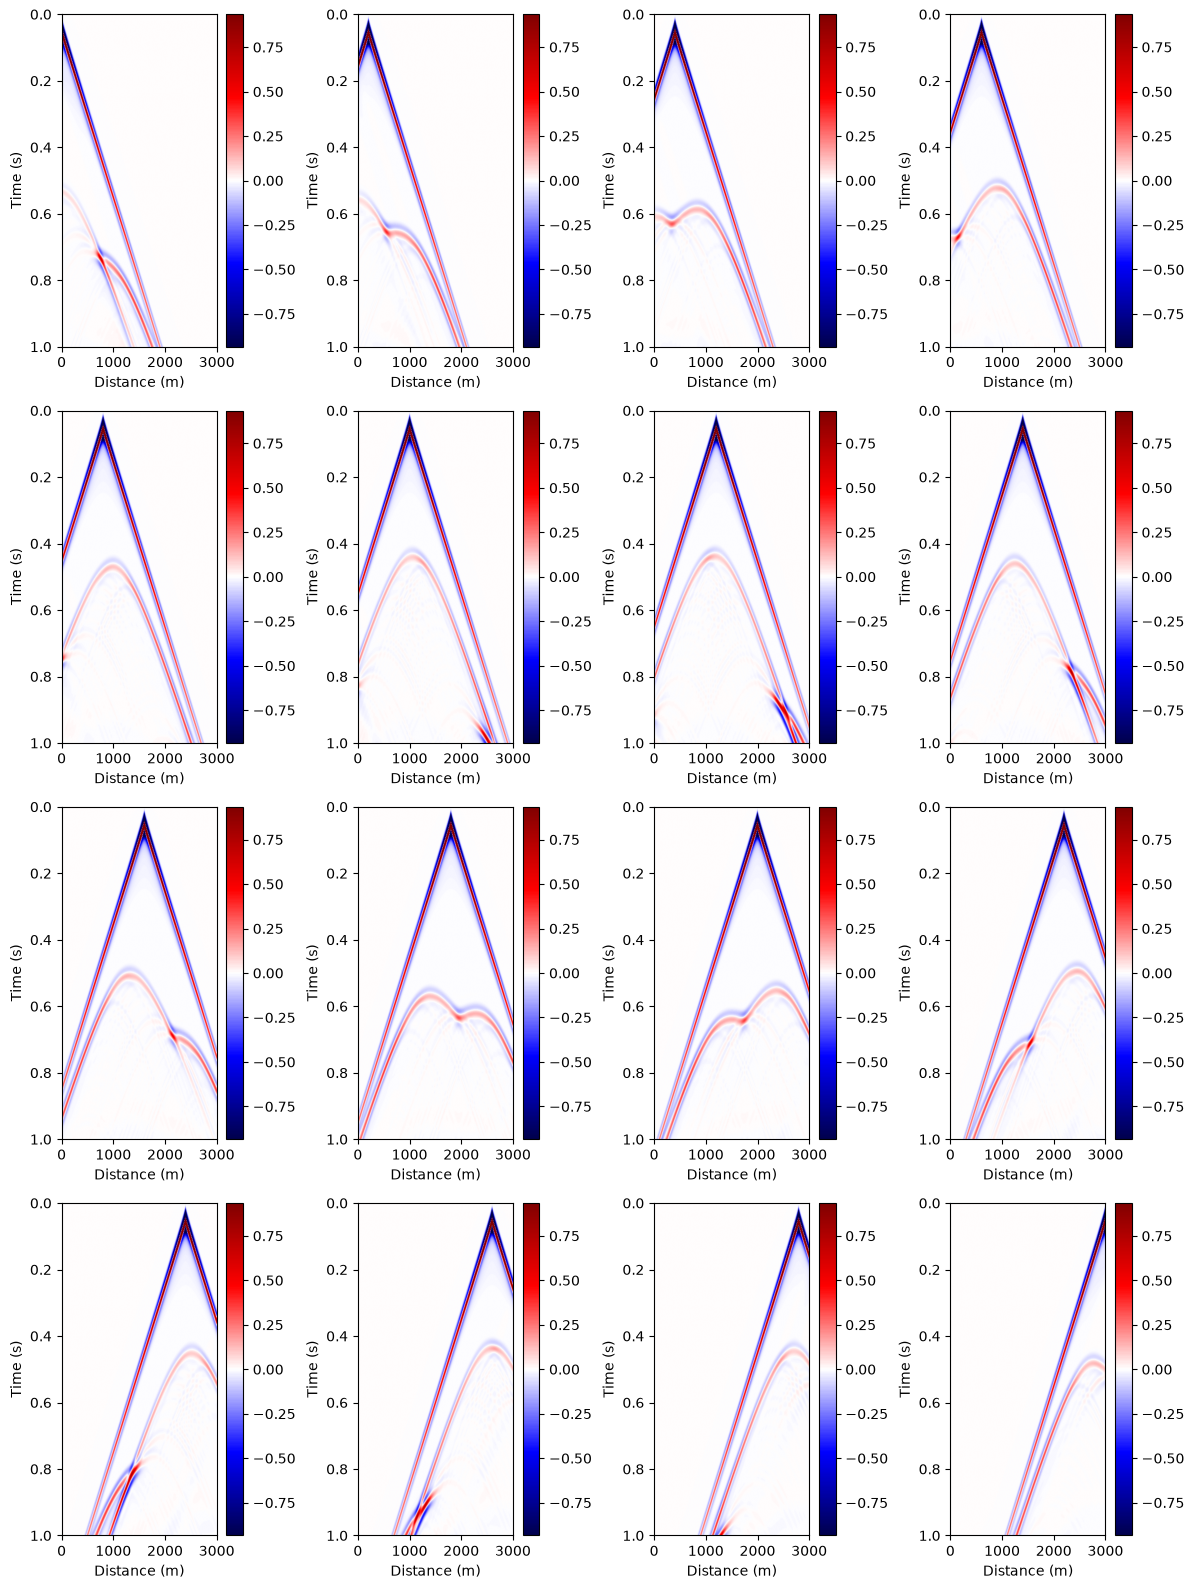

In [72]:
plt.figure(figsize=(12, 16))
for i in range(len(ix_src)):
    # Plot shot gather
    plt.subplot(4, 4, i + 1)
    vmax = np.max(shotgather[i])
    plt.imshow(
        shotgather[i],
        extent=[0,x_max,tmax,0],
        aspect='auto',
        cmap="seismic",
        vmin=-vmax/10,
        vmax=vmax/10,
        )
    plt.xlabel("Distance (m)")
    plt.ylabel("Time (s)")
    plt.colorbar()

plt.tight_layout()
plt.show()

In [73]:
# Damping boundary
n_abs = 40
velocity_extent, sigma = damping_boundary(
    velocity_smooth,
    dx,
    dz,
    n_abs,
    reflection=1e-6,
    power=2
)
# Finite-difference order
order = 8
coeff = fd_coefficients(order)
coeff = np.asarray(coeff,dtype=np.float64)

snapshot_steps = np.array([100])
#===========================================
# Remove direct wave
#===========================================
shotgather_direct = np.zeros((len(ix_src),len(wavelet),velocity.shape[1]),dtype=np.float64)
shotgather_remove_direct = np.zeros((len(ix_src),len(wavelet),velocity.shape[1]),dtype=np.float64)
for i in range(len(ix_src)):
    shotgather_direct[i] = forward_acoustic_solver(
        velocity_extent,
        wavelet,
        coeff,
        ix_src[i],
        iz_src,
        dx,
        dz,
        dt,
        snapshot_steps,
        sigma,
        n_abs,
        )[1]
    shotgather_remove_direct[i] = shotgather[i] - shotgather_direct[i]

Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s


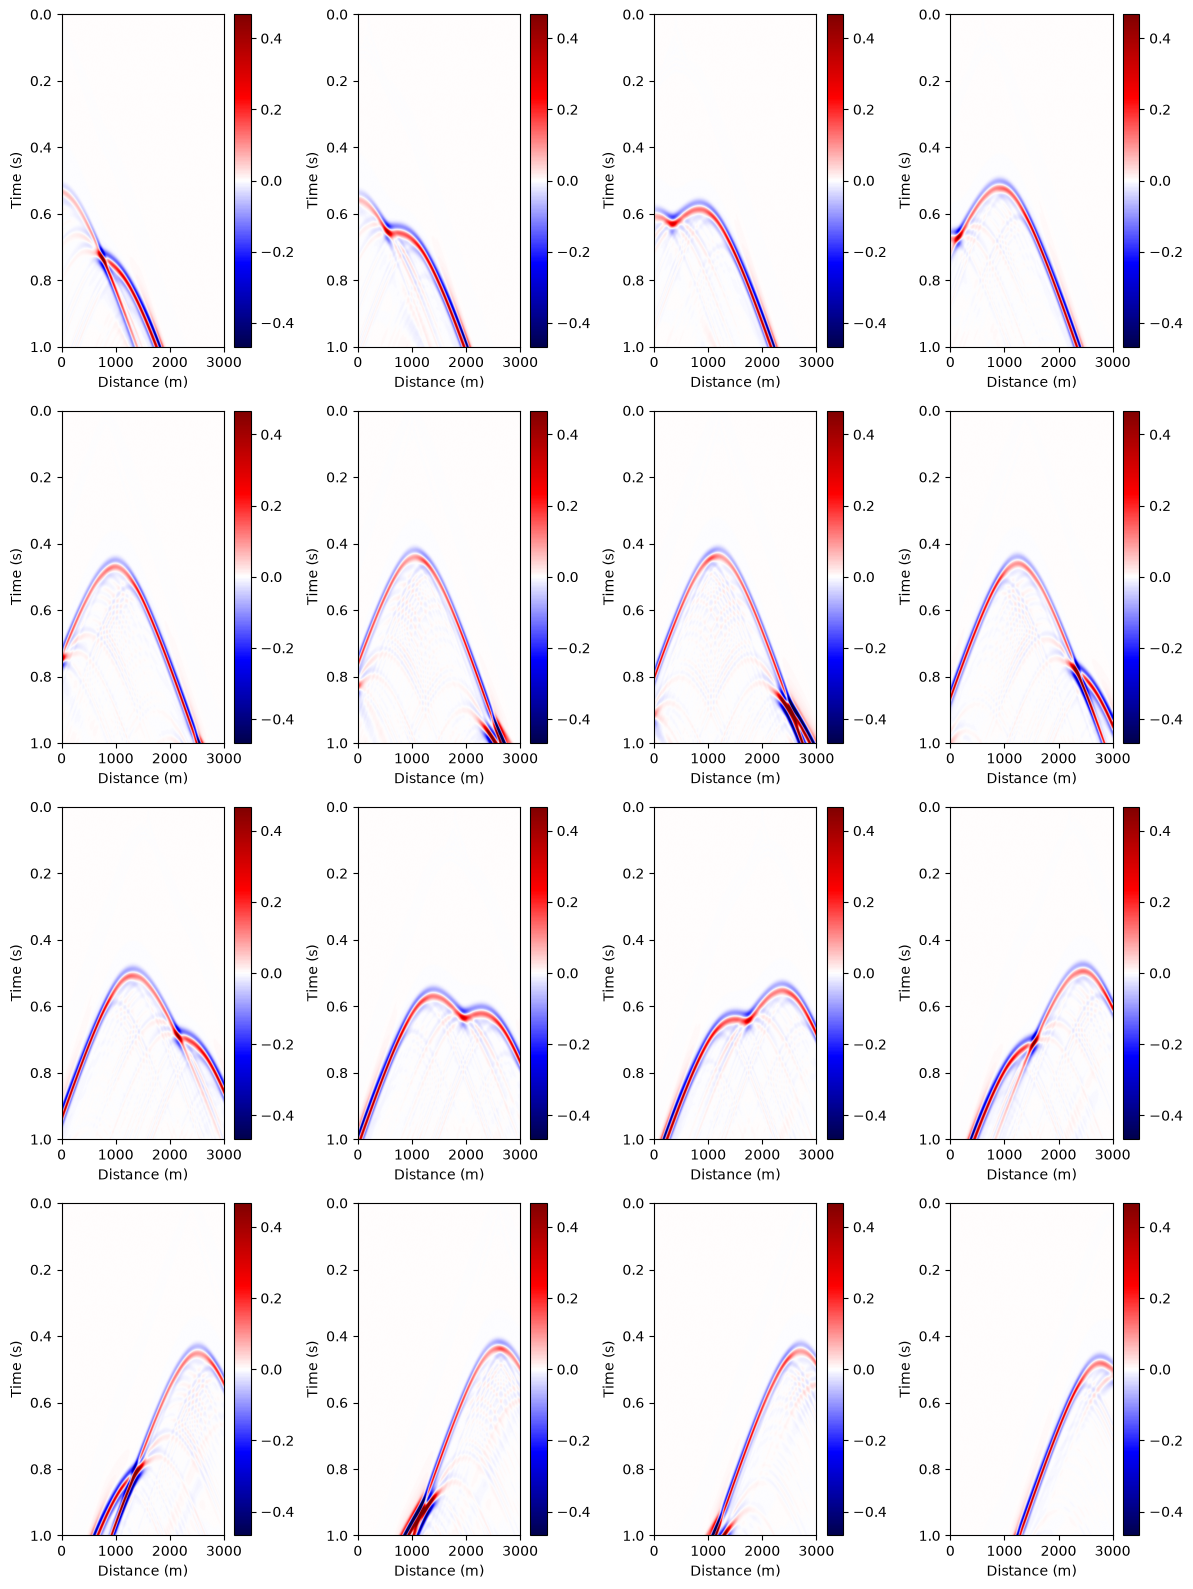

In [74]:
plt.figure(figsize=(12, 16))
for i in range(len(ix_src)):
    # Plot shot gather
    plt.subplot(4, 4, i + 1)
    vmax = np.max(shotgather[i])/2
    plt.imshow(
        shotgather_remove_direct[i],
        extent=[0,x_max,tmax,0],
        aspect='auto',
        cmap="seismic",
        vmin=-vmax/10,
        vmax=vmax/10,
        )
    plt.xlabel("Distance (m)")
    plt.ylabel("Time (s)")
    plt.colorbar()

plt.tight_layout()
plt.show()

In [75]:
image1,image2 = RTM_imaging(
    velocity_smooth,
    dx,
    dz,
    dt,
    tmax,
    order,
    wavelet,
    ix_src,   # ix_src = [x1,x2,x3,...]
    iz_src,   # depth of source
    shotgather_remove_direct, # shotgather = [n_source,nt,nx]
    n_abs = 40,
)

Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s
181 381 1001
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Time step: 1001 / 1001   Time: 1.0010000000000001 s
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001  

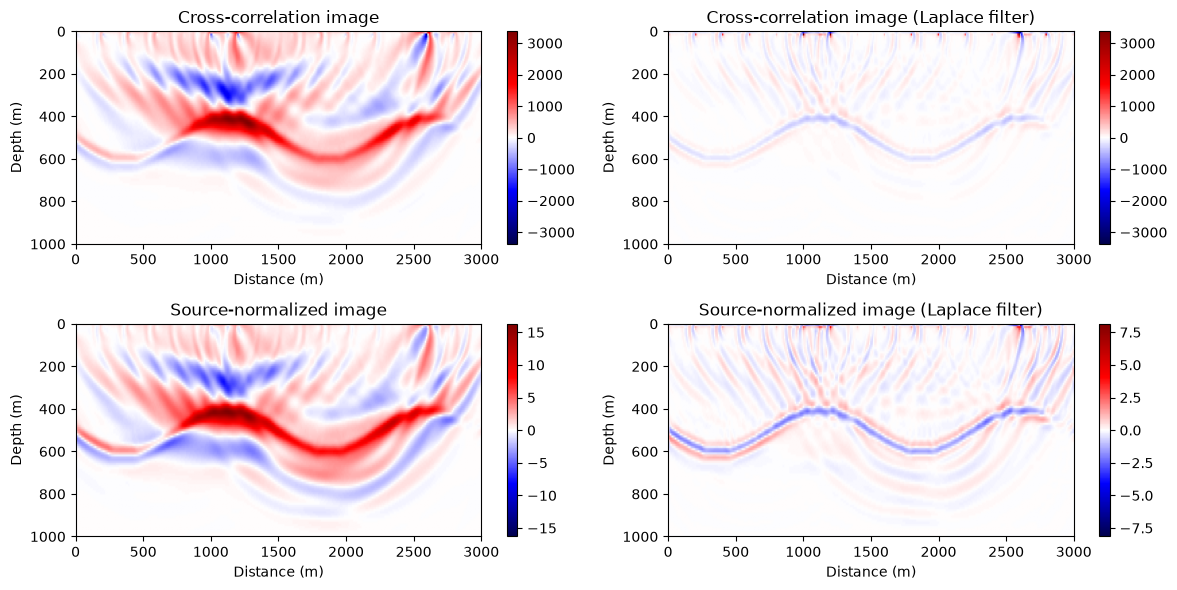

In [81]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
vmax = np.max(image1)
plt.imshow(
    image1,
    extent=[0,x_max,z_max,0],
    aspect='auto',
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title('Cross-correlation image')
plt.colorbar()

plt.subplot(2,2,2)
vmax = np.max(image1)
image1_laplace = laplace(image1)
plt.imshow(
    image1_laplace,
    extent=[0,x_max,z_max,0],
    aspect='auto',
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title('Cross-correlation image (Laplace filter)')
plt.colorbar()

plt.subplot(2,2,3)
vmax = np.max(image2)
plt.imshow(
    image2,
    extent=[0,x_max,z_max,0],
    aspect='auto',
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title('Source-normalized image')
plt.colorbar()

plt.subplot(2,2,4)
vmax = np.max(image2)/2
image2_laplace = laplace(image2)
plt.imshow(
    image2_laplace,
    extent=[0,x_max,z_max,0],
    aspect='auto',
    cmap="seismic",
    vmin=-vmax,
    vmax=vmax,
    )
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.title('Source-normalized image (Laplace filter)')
plt.colorbar()

plt.tight_layout()
plt.show()